In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from scipy.integrate import simpson
from scipy.signal import find_peaks
from scipy.special import loggamma
from BayesianSignal import *

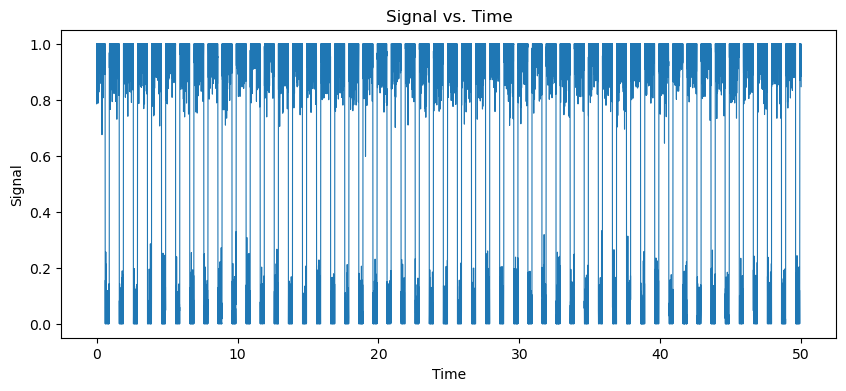

-16889261.49465706 -9456.587326622419


In [2]:
period = 1
omega = 2*np.pi/period
t, signal = make_dummy_signal(time_total=50, n_timesteps=10000, period=1, signal_type="square")

plt.figure(figsize=(10, 4))
plt.plot(t, signal, lw=0.8)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Signal vs. Time')
plt.show()

Omega, Pw, lr = Omega_Curve(t, signal, omega_min=1, omega_max=20, omega_steps=300, phi_steps=10, m_min=5, m_max=20, return_likelihood_ratio=True)


# Find best omega
omega_best = best_omega(Omega, Pw)

# Phase fold the signal with the best omega, using a "typical" phi and m
phi_best = 0
m_best = 20
folded_signal, bin_phases = phase_fold(t, signal, omega=omega_best, phi=phi_best, num_bins=m_best)

In [3]:
lr

-16879804.907330435

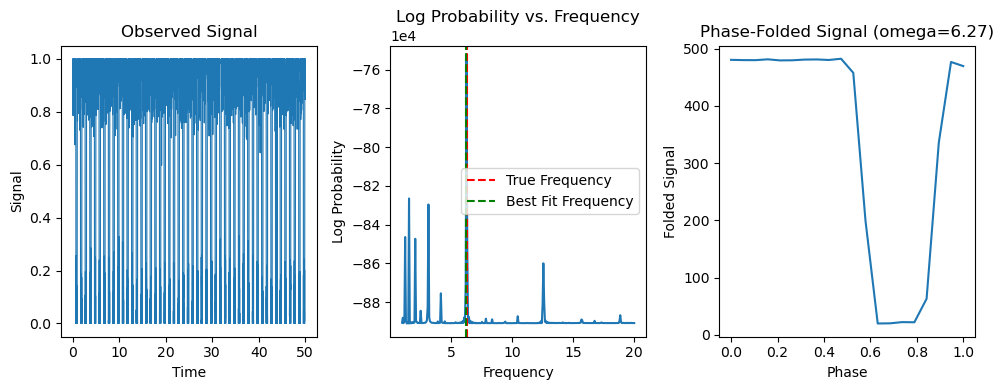

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# First subplot: the signal versus time
axs[0].plot(t, signal, lw=0.8)
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Signal')
axs[0].set_title('Observed Signal')

# Second subplot: Omega vs. Pw (current plot)
axs[1].plot(Omega, Pw)
axs[1].axvline(x=omega, color='r', linestyle='--', label='True Frequency')
axs[1].axvline(x=omega_best, color='g', linestyle='--', label='Best Fit Frequency')
axs[1].set_xlabel('Frequency')
axs[1].set_ylabel("Log Probability")
axs[1].legend()
axs[1].set_title('Log Probability vs. Frequency')
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(4,4))

# Third subplot: Phase-folded signal using best-fit frequency
axs[2].plot(bin_phases, folded_signal)
axs[2].set_xlabel('Phase')
axs[2].set_ylabel('Folded Signal')
axs[2].set_title(f'Phase-Folded Signal (omega={omega_best:.2f})')

plt.tight_layout()
plt.show()
